# Part 3: Natural Language Processing

## 1. Setup

Installing the required packages


In [1]:
import sys
!{sys.executable} -m pip install gensim gradio -q
print("Setup complete")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 62.1 MB/s eta 0:00:00
Setup complete


In [2]:
import os

FILE_PATH = '/content/drive/MyDrive/AIML_FINAL_COURSEWORK/hatevsoffensive_language.csv'

if os.path.exists(FILE_PATH):
    print("Dataset found")
else:
    print(f"Dataset NOT found")

Dataset found


In [3]:
#imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# imports for text preprocessing
import re
import string
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              accuracy_score, f1_score)
from sklearn.utils.class_weight import compute_class_weight

# Keras/TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Embedding, SimpleRNN, LSTM, Bidirectional,
                                      Dense, Dropout, SpatialDropout1D)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical

# Visualisation
from wordcloud import WordCloud

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"NumPy:      {np.__version__}")
print(f"Pandas:     {pd.__version__}")

TensorFlow: 2.20.0
NumPy:      2.0.2
Pandas:     2.2.2


## 2. Load Dataset

The dataset contains tweets labelled as one of three classes. Note that the source CSV has a typo in the label "hate speec" which is missing the letter h in it.

In [4]:
df = pd.read_csv(FILE_PATH)

print("DATASET OVERVIEW (raw)")
print(f"Total records : {len(df):,}")
print(f"Columns       : {df.columns.tolist()}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Raw labels    : {df['label'].unique().tolist()}")

# --- Fix the typo ---
df['label'] = df['label'].replace('hate speec', 'hate speech')
print(f"Fixed labels  : {df['label'].unique().tolist()}")

print("\nFirst 3 rows:")
print(df.head(3).to_string())

DATASET OVERVIEW (raw)
Total records : 24,783
Columns       : ['label', 'text']
Missing values: 0
Raw labels    : ['neither', 'offensive language', 'hate speec']
Fixed labels  : ['neither', 'offensive language', 'hate speech']

First 3 rows:
                label                                                                                                                                          text
0             neither  !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man you should always take the trash out...
1  offensive language                                                         !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!
2  offensive language                      !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You be confused as shit


In [5]:
print("Label distribution:")
print(df['label'].value_counts())
print()
print("As percentages:")
print((df['label'].value_counts(normalize=True) * 100).round(2))

Label distribution:
label
offensive language    19190
neither                4163
hate speech            1430
Name: count, dtype: int64

As percentages:
label
offensive language    77.43
neither               16.80
hate speech            5.77
Name: proportion, dtype: float64


## 3. Exploratory Data Analysis

The dataset is highly imbalanced where offensive language is roughly 77% of the data, while hate speech is only ~6%. This imbalance is the central challenge of this task and a major reason a  model achieves "high accuracy" while completely failing on the minority class.

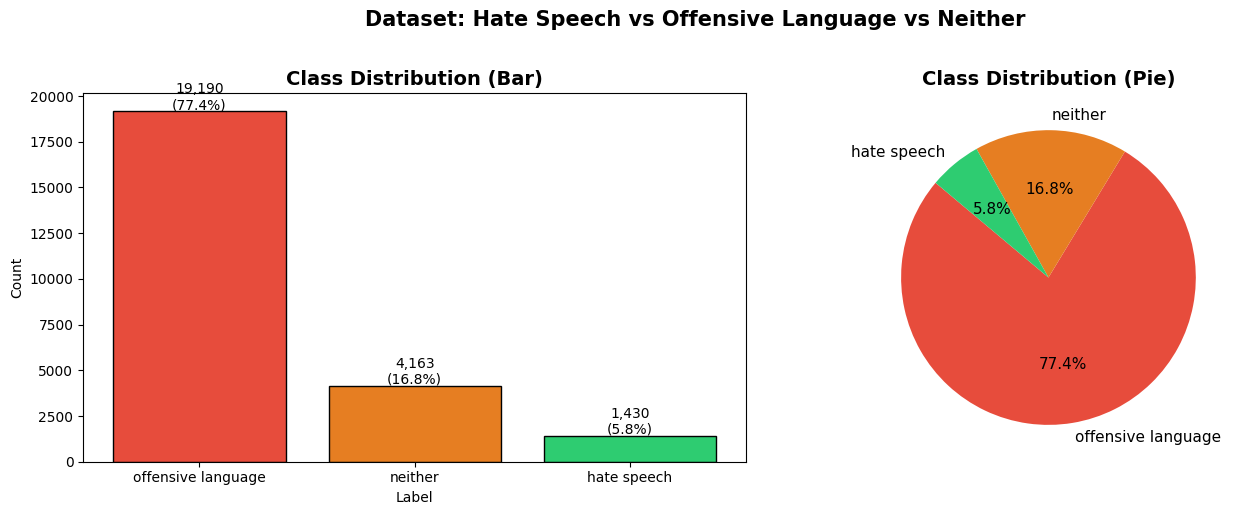

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

label_counts = df['label'].value_counts()
colors = ['#e74c3c', '#e67e22', '#2ecc71']

#Bar Chart
axes[0].bar(label_counts.index, label_counts.values, color=colors, edgecolor='black')
axes[0].set_title('Class Distribution (Bar)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Count')
for i, (lbl, cnt) in enumerate(zip(label_counts.index, label_counts.values)):
    axes[0].text(i, cnt + 100, f'{cnt:,}\n({cnt/len(df)*100:.1f}%)',
                 ha='center', fontsize=10)

#Pie Chart
axes[1].pie(label_counts.values, labels=label_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=140, textprops={'fontsize': 11})
axes[1].set_title('Class Distribution (Pie)', fontsize=14, fontweight='bold')

plt.suptitle('Dataset: Hate Speech vs Offensive Language vs Neither',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


### Observation

The dataset is highly imbalanced:

- Offensive language constitutes approximately 77% of the dataset.
- Hate speech represents only around 6% of the data.

This imbalance may bias the model toward the majority class. Therefore:

- Class weights should be applied during training.
- Macro-averaged evaluation metrics should be used for fair performance assessment across all classes.

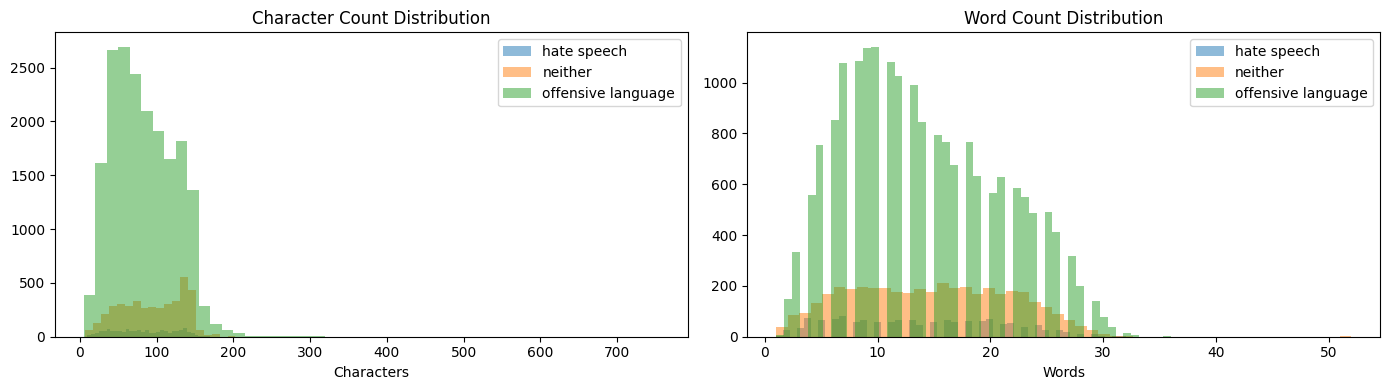


Word Count Statistics:
count    24783.0
mean        14.1
std          6.8
min          1.0
25%          9.0
50%         13.0
75%         19.0
max         52.0
Name: word_count, dtype: float64

95th percentile word count: 26
This will set our MAX_SEQUENCE_LENGTH for padding.


In [7]:
# Text length distributions
df['char_count'] = df['text'].str.len()
df['word_count'] = df['text'].str.split().str.len()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, grp in df.groupby('label'):
    axes[0].hist(grp['char_count'], bins=50, alpha=0.5, label=label)
    axes[1].hist(grp['word_count'], bins=50, alpha=0.5, label=label)

axes[0].set_title('Character Count Distribution')
axes[0].set_xlabel('Characters'); axes[0].legend()
axes[1].set_title('Word Count Distribution')
axes[1].set_xlabel('Words'); axes[1].legend()

plt.tight_layout()
plt.savefig('text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nWord Count Statistics:")
print(df['word_count'].describe().round(1))
print(f"\n95th percentile word count: {df['word_count'].quantile(0.95):.0f}")
print("This will set our MAX_SEQUENCE_LENGTH for padding.")

## 4. Text Preprocessing

Standard tweet-cleaning pipeline.
- We keep not, no, nor in the text, these negations matter for sentiment/intent.
- We expand contractions (don't transformed to do not) so negations aren't lost.
- We remove URLs, mentions, hashtags, and HTML entities (&amp;).
- We lemmatize (running transformed to run) using WordNet to reduce vocabulary size.

In [8]:
lemmatizer = WordNetLemmatizer()
# Keep negation words — important for distinguishing "not racist" from "racist"
STOP_WORDS = set(stopwords.words('english')) - {"not", "no", "nor"}

CONTRACTIONS = {
    "don't": "do not", "doesn't": "does not", "didn't": "did not",
    "won't": "will not", "can't": "cannot", "isn't": "is not",
    "aren't": "are not", "wasn't": "was not", "weren't": "were not",
    "haven't": "have not", "hasn't": "has not", "hadn't": "had not",
    "wouldn't": "would not", "couldn't": "could not", "shouldn't": "should not",
    "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would",
    "you're": "you are", "you've": "you have", "you'll": "you will",
    "he's": "he is", "she's": "she is", "it's": "it is", "that's": "that is",
    "there's": "there is", "they're": "they are", "we're": "we are",
    "let's": "let us", "what's": "what is", "who's": "who is",
    "ain't": "is not", "y'all": "you all"
}

def expand_contractions(text):
    for c, e in CONTRACTIONS.items():
        text = re.sub(rf"\b{c}\b", e, text)
    return text

def clean_text(text):
    """Full tweet cleaning pipeline."""
    #converting to lower case
    text = text.lower()
    #expand contractions before removing punctuation
    text = expand_contractions(text)
    #remove URLs
    text = re.sub(r'http\S+|www\.\S+', '', text)
    #remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    #remove HTML entities (&amp; etc.)
    text = re.sub(r'&\w+;', '', text)
    #remove non-letters
    text = re.sub(r'[^a-z\s]', '', text)
    #collapse whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    #tokenize, remove stopwords, lemmatize, drop short tokens and 'rt'
    tokens = text.split()
    tokens = [
        lemmatizer.lemmatize(w)
        for w in tokens
        if w not in STOP_WORDS and w != "rt" and len(w) > 1
    ]
    return ' '.join(tokens)

# Demo
sample = "!!! RT @mayasolovely: As a woman you shouldn't have to feel like you're competing"
print("RAW   :", sample)
print("CLEAN :", clean_text(sample))

RAW   : !!! RT @mayasolovely: As a woman you shouldn't have to feel like you're competing
CLEAN : woman not feel like competing


In [9]:
# clean all the tweets
df['clean_text'] = df['text'].apply(clean_text)

# drop rows that became empty after cleaning
df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

print(f"Cleaning complete!")
print(f"Remaining records: {len(df):,}")

print("\nBefore vs After cleaning (first 3 examples):")
for i in range(3):
    print(f"\n[{i+1}] LABEL: {df['label'][i]}")
    print(f"    RAW  : {df['text'][i][:100]}...")
    print(f"    CLEAN: {df['clean_text'][i][:100]}")

Cleaning complete!
Remaining records: 24,763

Before vs After cleaning (first 3 examples):

[1] LABEL: neither
    RAW  : !!! RT @mayasolovely: As a woman you shouldn't complain about cleaning up your house. &amp; as a man...
    CLEAN: woman not complain cleaning house man always take trash

[2] LABEL: offensive language
    RAW  : !!!!! RT @mleew17: boy dats cold...tyga dwn bad for cuffin dat hoe in the 1st place!!...
    CLEAN: boy dat coldtyga dwn bad cuffin dat hoe st place

[3] LABEL: offensive language
    RAW  : !!!!!!! RT @UrKindOfBrand Dawg!!!! RT @80sbaby4life: You ever fuck a bitch and she start to cry? You...
    CLEAN: dawg ever fuck bitch start cry confused shit


### 4.1 Word Clouds: Shows Most Frequent Words Per Class

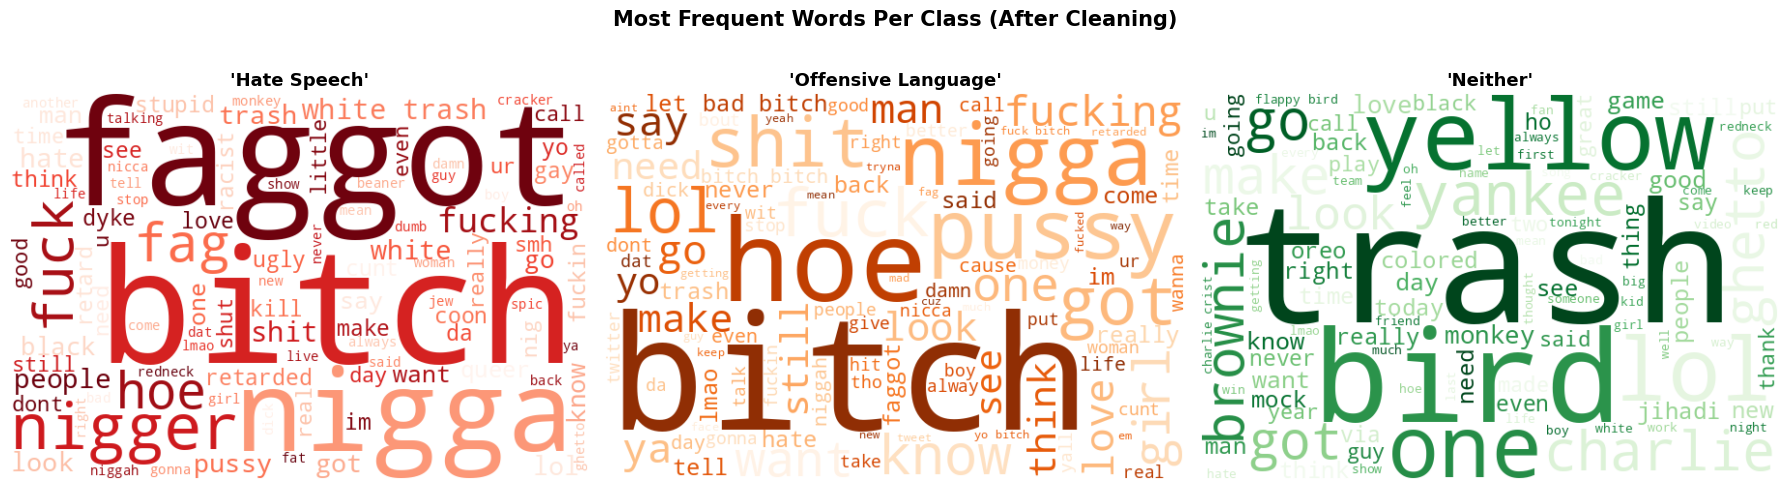

In [10]:
# check whether the cleaned text column already exists to prevent reprocessing of data multiple times
if 'clean_text' not in df.columns:

    # Apply text preprocessing
    df['clean_text'] = df['text'].apply(clean_text)
    # Remove empty rows after cleaning
    df = df[df['clean_text'].str.len() > 0].reset_index(drop=True)

color_maps = {'hate speech': 'Reds', 'offensive language': 'Oranges', 'neither': 'Greens'}
# Create 3 side-by-side plots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Generate word cloud for each label
for ax, label in zip(axes, ['hate speech', 'offensive language', 'neither']):
    text_combined = ' '.join(df[df['label'] == label]['clean_text'].values)
    wc = WordCloud(width=600, height=400, max_words=100,
                   background_color='white',
                   colormap=color_maps[label]).generate(text_combined)
    ax.imshow(wc, interpolation='bilinear')
    ax.set_title(f"'{label.title()}'", fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Most Frequent Words Per Class (After Cleaning)',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()

### Observation

Hate speech and offensive language share many common vocabulary items, including slurs and profanity. However, they differ primarily in their target and intent

This linguistic similarity is one of the core challenges of the classification task.

## 5. Label Encoding, Train/Test Split, and Class Weights

In [11]:
# Convert text labels into numeric values
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['label'])

# Display label mappings
print("Label encoding:")
for cls, code in zip(le.classes_, le.transform(le.classes_)):
    print(f"  '{cls}' = {code}")

# Total number of unique classes
NUM_CLASSES = len(le.classes_)
print(f"\nNumber of classes: {NUM_CLASSES}")

# Convert labels into one-hot encoded format
y = to_categorical(df['label_encoded'], num_classes=NUM_CLASSES)

# Split dataset into 80% training and 20% testing
# Stratified split keeps class distribution balanced
X_train_text, X_test_text, y_train, y_test = train_test_split(
    df['clean_text'].values,
    y,
    test_size=0.2,
    random_state=SEED,
    stratify=df['label_encoded']
)

# Print dataset split information
print(f"\nTrain set: {len(X_train_text):,} ({len(X_train_text)/len(df)*100:.0f}%)")
print(f"Test set : {len(X_test_text):,} ({len(X_test_text)/len(df)*100:.0f}%)")
print("stratify=True ensures both splits maintain the original class ratio.")

Label encoding:
  'hate speech' = 0
  'neither' = 1
  'offensive language' = 2

Number of classes: 3

Train set: 19,810 (80%)
Test set : 4,953 (20%)
stratify=True ensures both splits maintain the original class ratio.


In [12]:
# Class weights to combat imbalance
y_train_int = np.argmax(y_train, axis=1)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_int),
    y=y_train_int
)
class_weights = {i: w for i, w in enumerate(class_weights_arr)}

print("Class weights (will be applied during training):")
for i, cls in enumerate(le.classes_):
    print(f"  {i} '{cls}' = weight {class_weights[i]:.3f}")

print("\nIntuition: hate speech examples will count 5 to 6 times more during loss\n computation than offensive language examples.\n This forces the model to actually learn the minority class instead of ignoring it.")


Class weights (will be applied during training):
  0 'hate speech' = weight 5.792
  1 'neither' = weight 1.985
  2 'offensive language' = weight 0.430

Intuition: hate speech examples will count 5 to 6 times more during loss
 computation than offensive language examples.
 This forces the model to actually learn the minority class instead of ignoring it.


## 6. Tokenisation and Padding

We:
- Set MAX_SEQ_LEN to the 95th percentile of word counts (so we don't pad most tweets to extreme lengths).
- Cap vocab at 20,000 most frequent words.
- Fit tokenizer ONLY on training data — fitting on the full dataset would be data leakage.

In [13]:
# Hyperparameters
VOCAB_SIZE = 20000
OOV_TOKEN = '<OOV>'

# Set sequence length using the 95th percentile of tweet lengths
word_counts = pd.Series([len(t.split()) for t in df['clean_text']])
MAX_SEQ_LEN = int(word_counts.quantile(0.95))
print(f"MAX_SEQ_LEN set to 95th percentile: {MAX_SEQ_LEN} tokens")

# Create and train tokenizer using only training data to avoid data leakage

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train_text)  # Fit only on train: no leakage

# Convert text into integer sequences
X_train_seq = tokenizer.texts_to_sequences(X_train_text)
X_test_seq  = tokenizer.texts_to_sequences(X_test_text)

# Pad sequences so all inputs have equal length
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_SEQ_LEN,
                            padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_SEQ_LEN,
                            padding='post', truncating='post')

print(f"\nVocabulary size (unique words found): {len(tokenizer.word_index):,}")
print(f"Using top {VOCAB_SIZE:,} words.")
print(f"X_train shape: {X_train_pad.shape}  (samples × sequence_length)")
print(f"X_test  shape: {X_test_pad.shape}")

print("\nExample:")
print(f"  Text  : {X_train_text[0]}")
print(f"  First 15 Tokens: {X_train_pad[0][:15]}")

MAX_SEQ_LEN set to 95th percentile: 14 tokens

Vocabulary size (unique words found): 15,996
Using top 20,000 words.
X_train shape: (19810, 14)  (samples × sequence_length)
X_test  shape: (4953, 14)

Example:
  Text  : smoke good weed bad bitch
  First 15 Tokens: [382  31 297  29   2   0   0   0   0   0   0   0   0   0]


## 7. Model 1 SimpleRNN with Trainable Embedding

A baseline RNN. We expect it to struggle because:
- SimpleRNN suffers from vanishing gradients on longer sequences.
- It learns word embeddings from scratch on a small dataset (~24k tweets).

In [14]:
# Set embedding vector size
EMBEDDING_DIM = 64
# Clear previous TensorFlow session and set random seeds
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

# Build SimpleRNN model
model1 = Sequential(name='Model1_SimpleRNN')

# Input layer
model1.add(tf.keras.Input(shape=(MAX_SEQ_LEN,)))

# Convert word indices into dense word embeddings
model1.add(Embedding(input_dim=VOCAB_SIZE, output_dim=EMBEDDING_DIM))
# Drop entire embedding features to reduce overfitting
model1.add(SpatialDropout1D(0.3))   # drops entire feature columns which is better for NLP

# Output layer for multi-class classification
model1.add(SimpleRNN(64, dropout=0.2, recurrent_dropout=0.2))
model1.add(Dense(NUM_CLASSES, activation='softmax'))

model1.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model1.summary()

Model: "Model1_SimpleRNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 14, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,288,451 (4.92 MB)

 Trainable params: 1,288,451 (4.92 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
import time

early_stop = EarlyStopping(monitor='val_loss', patience=5,
                           restore_best_weights=True, verbose=1)

print("Training Model 1 (SimpleRNN) with class weights...")
t0 = time.time()
history1 = model1.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    class_weight=class_weights,
    verbose=1
)
training_time1 = time.time() - t0
print(f"\nModel 1 training time: {training_time1:.1f} seconds")

Training Model 1 (SimpleRNN) with class weights...
Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 29ms/step - accuracy: 0.5757 - loss: 0.9959 - val_accuracy: 0.8375 - val_loss: 0.6016
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7354 - loss: 0.7705 - val_accuracy: 0.8142 - val_loss: 0.6426
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.7317 - loss: 0.6552 - val_accuracy: 0.8390 - val_loss: 0.5835
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - accuracy: 0.7594 - loss: 0.5540 - val_accuracy: 0.8339 - val_loss: 0.5886
Epoch 5/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7994 - loss: 0.4791 - val_accuracy: 0.8587 - val_loss: 0.4713
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.8211 - loss: 0.4323 - val_accuracy: 0.7895 - val_loss: 0.6143
Epoch 7/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 28ms/step - accuracy: 0.8497 - loss: 0.3694 - val_accuracy: 0.8455 - val_loss: 0.4924
Epoch 8/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 9s 3

## 8. Model 2 LSTM with Trainable Embedding

LSTM has gating (forget/input/output) so it handles long-range dependencies better than SimpleRNN.

In [16]:
# Clear previous TensorFlow session and set random seeds
tf.keras.backend.clear_session()
tf.random.set_seed(SEED)
np.random.seed(SEED)

# Build LSTM model
model2 = Sequential(name='Model2_LSTM')

# Input layer
model2.add(tf.keras.Input(shape=(MAX_SEQ_LEN,)))

# Convert word indices into dense word embeddings
model2.add(
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM
    )
)

# Apply dropout on embedding features to reduce overfitting
model2.add(SpatialDropout1D(0.3))

# LSTM layer for learning long-term text dependencies
model2.add(
    LSTM(
        64,
        dropout=0.2,
        recurrent_dropout=0.2
    )
)

# Output layer for multi-class classification
model2.add(Dense(NUM_CLASSES, activation='softmax'))

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model2.summary()

Model: "Model2_LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 64)         │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 14, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,313,219 (5.01 MB)

 Trainable params: 1,313,219 (5.01 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Train the LSTM model using class weights
print("Training Model 2 (LSTM) with class weights")

# Record training start time
t0 = time.time()

# Stop training early if validation loss does not improve
early_stop2 = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop2],
    class_weight=class_weights,
    verbose=1
)
training_time2 = time.time() - t0
print(f"\nModel 2 training time: {training_time2:.1f} seconds")

Training Model 2 (LSTM) with class weights
Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 17s 47ms/step - accuracy: 0.6904 - loss: 0.7831 - val_accuracy: 0.8072 - val_loss: 0.5588
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 13s 46ms/step - accuracy: 0.8252 - loss: 0.4806 - val_accuracy: 0.8031 - val_loss: 0.4911
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 38ms/step - accuracy: 0.8497 - loss: 0.3718 - val_accuracy: 0.7446 - val_loss: 0.5815
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 22s 45ms/step - accuracy: 0.8654 - loss: 0.3103 - val_accuracy: 0.8031 - val_loss: 0.4987
Epoch 5/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.8862 - loss: 0.2511 - val_accuracy: 0.7996 - val_loss: 0.5862
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.9054 - loss: 0.2150 - val_accuracy: 0.7920 - val_loss: 0.6192
Epoch 7/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 20s 45ms/step - accuracy: 0.9088 - loss: 0.1911 - val_accuracy: 0.7855 - val_loss: 0.6078
Epoch 7: early stopping
Restoring model weights

## 9. Model 3 LSTM with Pretrained GloVe Twitter Embeddings

We download glove-twitter-50 — 50-dimensional vectors trained on 2 billion tweets. These vectors already encode semantic relationships from Twitter-style text, which should transfer well to our task.

In [18]:
import gensim.downloader as api

print("Downloading GloVe Twitter embeddings (~200MB, takes ~30s)...")
embedding_model = api.load('glove-twitter-50')
GLOVE_DIM = 50

print(f"\nGloVe model loaded!")
print(f"  Vector size: {GLOVE_DIM} dimensions")
print(f"  Vocabulary : {len(embedding_model.key_to_index):,} words")
print(f"  Example: 'hate' vector (first 5 dims): {embedding_model['hate'][:5]}")

[==================================================] 100.0% 199.5/199.5MB downloaded

GloVe model loaded!
  Vector size: 50 dimensions
  Vocabulary : 1,193,514 words
  Example: 'hate' vector (first 5 dims): [ 1.5455    0.43841   0.078383  0.33839  -0.94408 ]


In [19]:
# Create embedding matrix using pretrained GloVe vectors
word_index = tokenizer.word_index

embedding_matrix = np.zeros((VOCAB_SIZE, GLOVE_DIM))
found_count = 0
not_found_count = 0

# Match tokenizer words with GloVe embeddings
for word, idx in word_index.items():
  # Ignore words outside selected vocabulary size
    if idx < VOCAB_SIZE:
      # Add pretrained embedding if found
        if word in embedding_model:
            embedding_matrix[idx] = embedding_model[word]
            found_count += 1
        else:
            not_found_count += 1  # leave as zeros

total = found_count + not_found_count
print(f"Embedding matrix shape: {embedding_matrix.shape}")
print(f"Words found in GloVe : {found_count:,} / {total:,} "
      f"({found_count/total*100:.1f}%)")
print(f"Words NOT in GloVe   : {not_found_count:,} / {total:,} "
      f"({not_found_count/total*100:.1f}%)")
print("\nNot-found words become zero vectors. Most are slang, typos, or rare slurs.")

Embedding matrix shape: (20000, 50)
Words found in GloVe : 13,615 / 15,996 (85.1%)
Words NOT in GloVe   : 2,381 / 15,996 (14.9%)

Not-found words become zero vectors. Most are slang, typos, or rare slurs.


In [20]:
tf.keras.backend.clear_session()
tf.random.set_seed(SEED); np.random.seed(SEED)

model3 = Sequential(name='Model3_LSTM_GloVe')
model3.add(tf.keras.Input(shape=(MAX_SEQ_LEN,)))
model3.add(Embedding(
    input_dim=VOCAB_SIZE,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    trainable=False  # FREEZE GloVe weights — preserves pre-learned semantics
))
model3.add(SpatialDropout1D(0.3))
model3.add(LSTM(100, dropout=0.2, recurrent_dropout=0.2))
model3.add(Dense(NUM_CLASSES, activation='softmax'))

model3.compile(optimizer='adam',
               loss='categorical_crossentropy',
               metrics=['accuracy'])

model3.summary()
print("\nNote: Embedding layer is NON-TRAINABLE — GloVe vectors are frozen.")

Model: "Model3_LSTM_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 14, 50)         │     1,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 14, 50)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 100)            │        60,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │           303 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,703 (4.05 MB)

 Trainable params: 60,703 (237.12 KB)

 Non-trainable params: 1,000,000 (3.81 MB)


Note: Embedding layer is NON-TRAINABLE — GloVe vectors are frozen.


In [21]:
print("Training Model 3 (LSTM + GloVe) with class weights")
t0 = time.time()

early_stop3 = EarlyStopping(monitor='val_loss', patience=5,
                            restore_best_weights=True, verbose=1)

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=15,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop3],
    class_weight=class_weights,
    verbose=1
)
training_time3 = time.time() - t0
print(f"\nModel 3 training time: {training_time3:.1f} seconds")

Training Model 3 (LSTM + GloVe) with class weights
Epoch 1/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.6668 - loss: 0.8439 - val_accuracy: 0.8157 - val_loss: 0.5750
Epoch 2/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7257 - loss: 0.7342 - val_accuracy: 0.8238 - val_loss: 0.5632
Epoch 3/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 10s 37ms/step - accuracy: 0.7460 - loss: 0.6833 - val_accuracy: 0.8173 - val_loss: 0.5495
Epoch 4/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - accuracy: 0.7688 - loss: 0.6322 - val_accuracy: 0.8405 - val_loss: 0.4880
Epoch 5/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 11s 40ms/step - accuracy: 0.7771 - loss: 0.6184 - val_accuracy: 0.8269 - val_loss: 0.4893
Epoch 6/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 10s 38ms/step - accuracy: 0.7829 - loss: 0.5870 - val_accuracy: 0.8057 - val_loss: 0.5141
Epoch 7/15
279/279 ━━━━━━━━━━━━━━━━━━━━ 21s 40ms/step - accuracy: 0.7845 - loss: 0.5855 - val_accuracy: 0.8445 - val_loss: 0.4469
Epoch 8/15
279/279 ━━━━━━━━━━━━━━━━━━━━

## 11. Training Curves All Models

We plot training vs validation loss/accuracy to inspect convergence and overfitting.

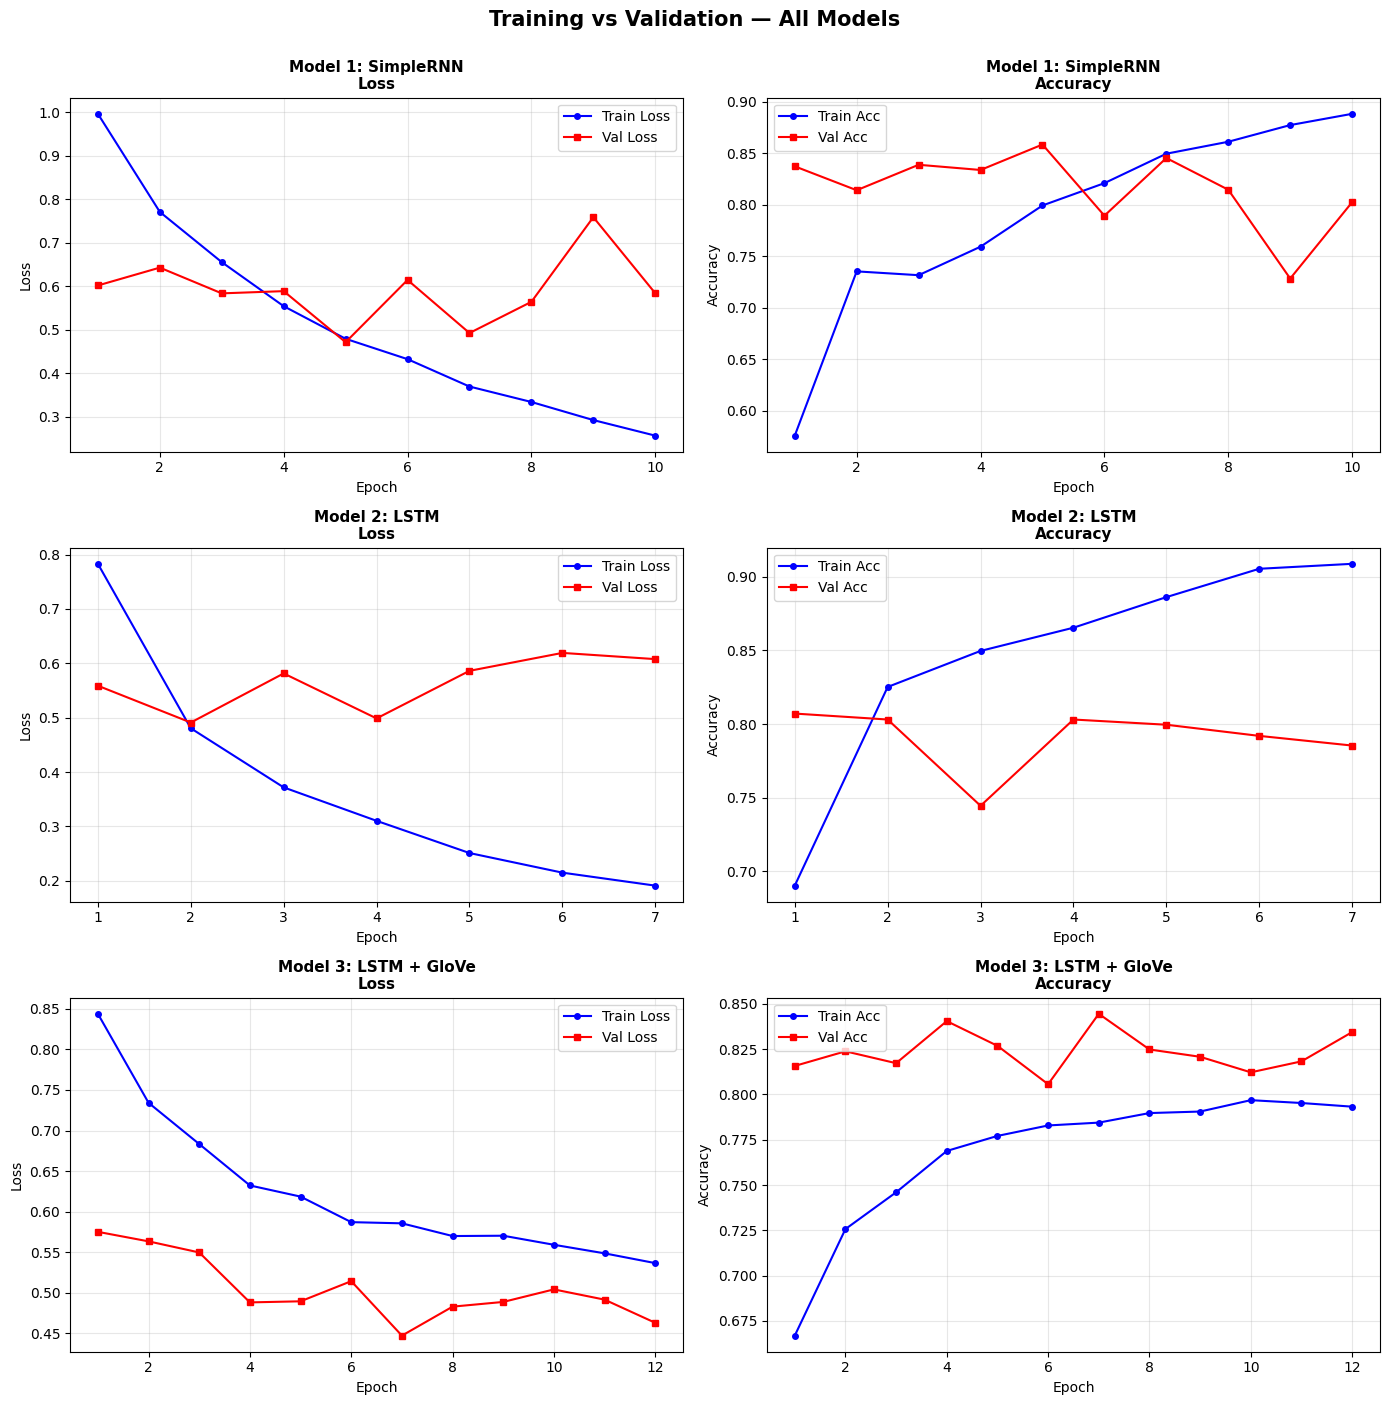

In [22]:
def plot_history(history, title, ax_loss, ax_acc):
    epochs = range(1, len(history.history['loss']) + 1)

    ax_loss.plot(epochs, history.history['loss'], 'b-o',
                 label='Train Loss', markersize=4)
    ax_loss.plot(epochs, history.history['val_loss'], 'r-s',
                 label='Val Loss', markersize=4)

    ax_loss.set_title(f'{title}\nLoss',
                      fontsize=11, fontweight='bold')
    ax_loss.set_xlabel('Epoch')
    ax_loss.set_ylabel('Loss')
    ax_loss.legend()
    ax_loss.grid(True, alpha=0.3)

    ax_acc.plot(epochs, history.history['accuracy'], 'b-o',
                label='Train Acc', markersize=4)
    ax_acc.plot(epochs, history.history['val_accuracy'], 'r-s',
                label='Val Acc', markersize=4)

    ax_acc.set_title(f'{title}\nAccuracy',
                     fontsize=11, fontweight='bold')
    ax_acc.set_xlabel('Epoch')
    ax_acc.set_ylabel('Accuracy')
    ax_acc.legend()
    ax_acc.grid(True, alpha=0.3)


fig, axes = plt.subplots(3, 2, figsize=(14, 14))

plot_history(history1, 'Model 1: SimpleRNN',
             axes[0][0], axes[0][1])

plot_history(history2, 'Model 2: LSTM',
             axes[1][0], axes[1][1])

plot_history(history3, 'Model 3: LSTM + GloVe',
             axes[2][0], axes[2][1])

plt.suptitle('Training vs Validation — All Models',
             fontsize=15, fontweight='bold', y=1.00)

plt.tight_layout()
plt.savefig('training_curves.png',
            dpi=150,
            bbox_inches='tight')

plt.show()

## 12. Evaluation — Test Accuracy, Macro F1, Per-Class F1, Confusion Matrices

**Important:** because the dataset is imbalanced, we look beyond raw accuracy. **Macro F1** and **per-class F1 for hate speech** are the metrics that actually tell us whether the model handles the minority class.

In [23]:
def evaluate_model(model, X_test, y_test, model_name, class_names):
    """Full evaluation: accuracy, macro F1, per-class F1, confusion matrix."""
    y_pred_probs = model.predict(X_test, verbose=0)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    acc = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro')
    per_class_f1 = f1_score(y_true, y_pred, average=None)

    print(f"  {model_name}")
    print(f"  Accuracy : {acc*100:.2f}%")
    print(f"  Macro F1 : {macro_f1:.4f}")
    print(f"  Per-class F1:")
    for cls, f1 in zip(class_names, per_class_f1):
        print(f"    {cls:<22s} {f1:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=class_names, digits=3))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.ylabel('Actual'); plt.xlabel('Predicted')
    plt.tight_layout()
    plt.savefig(f'confusion_matrix_{model_name.replace(" ", "_").replace(":", "")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    return y_pred, y_true, acc, macro_f1, per_class_f1

CLASS_NAMES = list(le.classes_)
print("Class names:", CLASS_NAMES)

Class names: ['hate speech', 'neither', 'offensive language']


  Model 1: SimpleRNN
  Accuracy : 85.56%
  Macro F1 : 0.7069
  Per-class F1:
    hate speech            0.3827
    neither                0.8258
    offensive language     0.9121

                    precision    recall  f1-score   support

       hate speech      0.305     0.512     0.383       285
           neither      0.768     0.893     0.826       831
offensive language      0.955     0.873     0.912      3837

          accuracy                          0.856      4953
         macro avg      0.676     0.759     0.707      4953
      weighted avg      0.886     0.856     0.867      4953



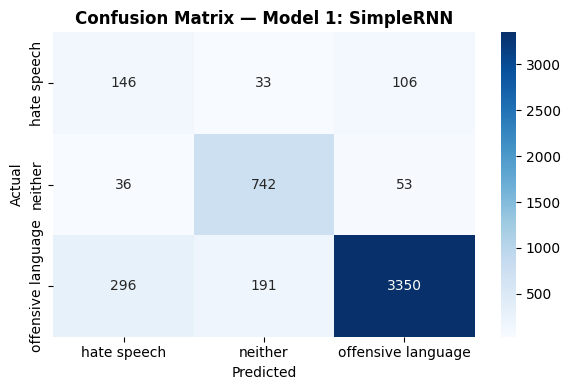

In [24]:
pred1, true1, acc1, mf1_1, pcf1_1 = evaluate_model(
    model1, X_test_pad, y_test, 'Model 1: SimpleRNN', CLASS_NAMES)

  Model 2: LSTM
  Accuracy : 80.72%
  Macro F1 : 0.6883
  Per-class F1:
    hate speech            0.3436
    neither                0.8464
    offensive language     0.8750

                    precision    recall  f1-score   support

       hate speech      0.227     0.705     0.344       285
           neither      0.805     0.892     0.846       831
offensive language      0.971     0.796     0.875      3837

          accuracy                          0.807      4953
         macro avg      0.668     0.798     0.688      4953
      weighted avg      0.900     0.807     0.840      4953



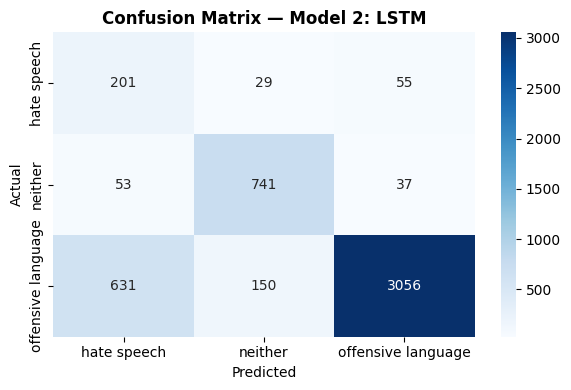

In [25]:
pred2, true2, acc2, mf1_2, pcf1_2 = evaluate_model(
    model2, X_test_pad, y_test, 'Model 2: LSTM', CLASS_NAMES)

  Model 3: LSTM + GloVe
  Accuracy : 83.77%
  Macro F1 : 0.7074
  Per-class F1:
    hate speech            0.3767
    neither                0.8468
    offensive language     0.8986

                    precision    recall  f1-score   support

       hate speech      0.266     0.646     0.377       285
           neither      0.786     0.918     0.847       831
offensive language      0.973     0.835     0.899      3837

          accuracy                          0.838      4953
         macro avg      0.675     0.799     0.707      4953
      weighted avg      0.901     0.838     0.860      4953



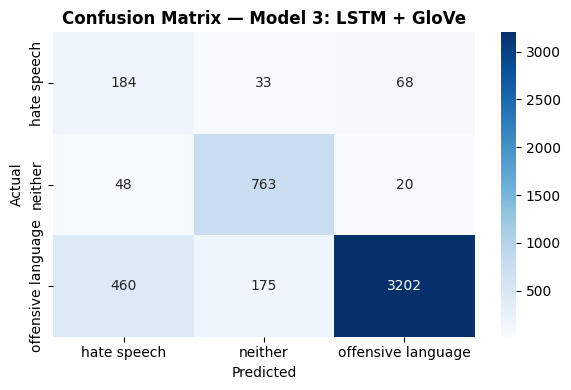

In [26]:
pred3, true3, acc3, mf1_3, pcf1_3 = evaluate_model(
    model3, X_test_pad, y_test, 'Model 3: LSTM + GloVe', CLASS_NAMES)

## 13. Final Model Comparison

We compare all four models on:
- Accuracy (misleading on imbalanced data, but standard)
- Macro F1 (treats all classes equally — the right metric here)
- Hate-speech F1 (does the model actually detect the minority class?)
- Training time (computational cost)
- Embedding type (random vs frozen pre-trained)

In [27]:
hate_idx = list(le.classes_).index('hate speech')

comparison_df = pd.DataFrame({
    'Model': [
        'Model 1: SimpleRNN',
        'Model 2: LSTM',
        'Model 3: LSTM + GloVe'
    ],

    'Test Accuracy (%)': [
        round(acc1 * 100, 2),
        round(acc2 * 100, 2),
        round(acc3 * 100, 2)
    ],

    'Macro F1': [
        round(mf1_1, 4),
        round(mf1_2, 4),
        round(mf1_3, 4)
    ],

    'Hate-speech F1': [
        round(pcf1_1[hate_idx], 4),
        round(pcf1_2[hate_idx], 4),
        round(pcf1_3[hate_idx], 4)
    ],

    'Training Time (s)': [
        round(training_time1, 1),
        round(training_time2, 1),
        round(training_time3, 1)
    ],

    'Epochs Run': [
        len(history1.history['loss']),
        len(history2.history['loss']),
        len(history3.history['loss'])
    ],

    'Embedding': [
        'Trainable (random)',
        'Trainable (random)',
        'Frozen GloVe Twitter-50'
    ]
})

print(comparison_df.to_string(index=False))

                Model  Test Accuracy (%)  Macro F1  Hate-speech F1  Training Time (s)  Epochs Run               Embedding
   Model 1: SimpleRNN              85.56    0.7069          0.3827               87.5          10      Trainable (random)
        Model 2: LSTM              80.72    0.6883          0.3436              109.5           7      Trainable (random)
Model 3: LSTM + GloVe              83.77    0.7074          0.3767              160.4          12 Frozen GloVe Twitter-50


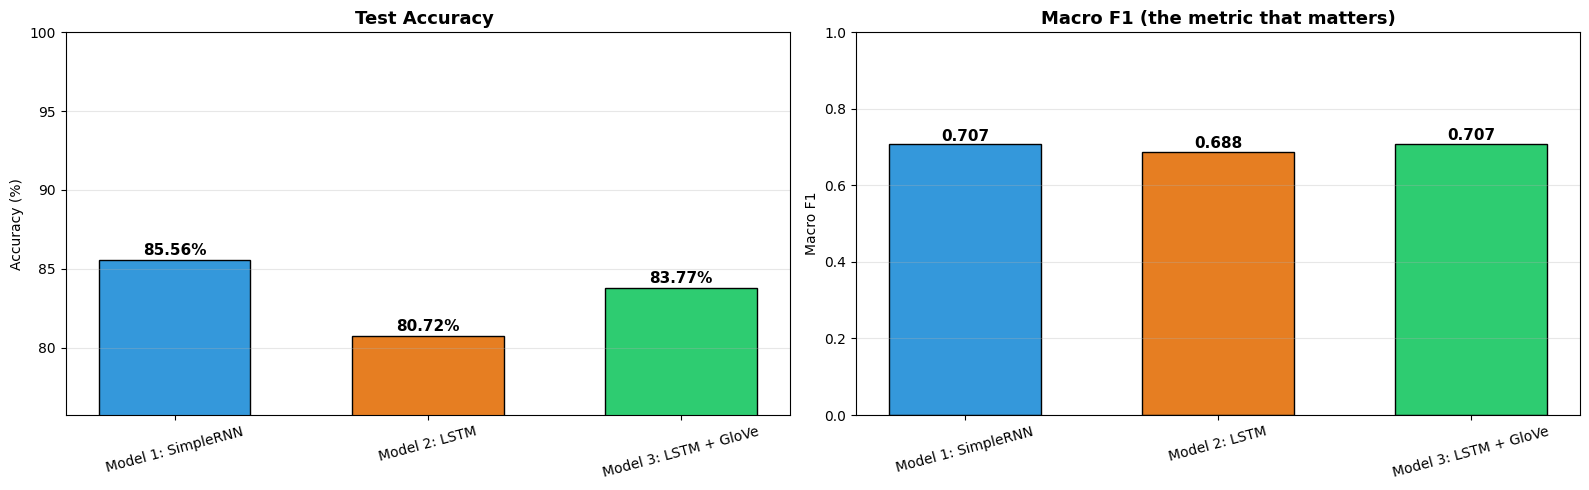

In [28]:
# --- Bar chart: Macro F1 (the right metric) ---
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

colors_bar = ['#3498db', '#e67e22', '#2ecc71']

# Accuracy
bars1 = axes[0].bar(
    comparison_df['Model'],
    comparison_df['Test Accuracy (%)'],
    color=colors_bar,
    edgecolor='black',
    width=0.6
)

axes[0].set_title(
    'Test Accuracy ',
    fontsize=13,
    fontweight='bold'
)

axes[0].set_ylabel('Accuracy (%)')

axes[0].set_ylim([
    min(comparison_df['Test Accuracy (%)']) - 5,
    100
])

axes[0].tick_params(axis='x', rotation=15)

for bar, val in zip(bars1, comparison_df['Test Accuracy (%)']):
    axes[0].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.3,
        f'{val:.2f}%',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

axes[0].grid(axis='y', alpha=0.3)

# Macro F1
bars2 = axes[1].bar(
    comparison_df['Model'],
    comparison_df['Macro F1'],
    color=colors_bar,
    edgecolor='black',
    width=0.6
)

axes[1].set_title(
    'Macro F1 (the metric that matters)',
    fontsize=13,
    fontweight='bold'
)

axes[1].set_ylabel('Macro F1')
axes[1].set_ylim([0, 1.0])

axes[1].tick_params(axis='x', rotation=15)

for bar, val in zip(bars2, comparison_df['Macro F1']):
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        fontsize=11,
        fontweight='bold'
    )

axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()

plt.savefig(
    'model_comparison.png',
    dpi=150,
    bbox_inches='tight'
)

plt.show()

## 14. Error Analysis

We pick the best model (by macro F1) and look at examples it gets wrong. The goal is to understand the failure modes, not just count errors.

In [29]:
# Pick best model by macro F1
all_macro_f1s = [mf1_1, mf1_2, mf1_3]

all_models = [
    model1,
    model2,
    model3
]

all_preds = [
    pred1,
    pred2,
    pred3
]

all_names = [
    'Model 1',
    'Model 2',
    'Model 3'
]

best_idx = int(np.argmax(all_macro_f1s))

best_pred = all_preds[best_idx]
best_true = true1  # all are the same y_true
best_name = all_names[best_idx]

print(f"Best model by Macro F1: {best_name} ({all_macro_f1s[best_idx]:.4f})\n")

label_decode = {
    i: name
    for i, name in enumerate(CLASS_NAMES)
}

misclassified_idx = np.where(best_pred != best_true)[0]

print(f"Total misclassified: {len(misclassified_idx)} / {len(best_true)}")

print(
    f"Error rate: "
    f"{len(misclassified_idx)/len(best_true)*100:.2f}%"
)

print("8 MISCLASSIFIED EXAMPLES ")

# Pick a balanced selection: try to show errors of each true class
np.random.seed(SEED)

shown = 0

for true_class in range(NUM_CLASSES):

    cls_errors = [
        i for i in misclassified_idx
        if best_true[i] == true_class
    ]

    sample = np.random.choice(
        cls_errors,
        size=min(3, len(cls_errors)),
        replace=False
    )

    for idx in sample:

        shown += 1

        print(f"\nExample {shown}:")
        print(f"  Cleaned text  : {X_test_text[idx][:120]}")
        print(f"  TRUE label    : {label_decode[best_true[idx]]}")
        print(f"  PREDICTED     : {label_decode[best_pred[idx]]}")

        if shown >= 8:
            break

    if shown >= 8:
        break

Best model by Macro F1: Model 3 (0.7074)

Total misclassified: 804 / 4953
Error rate: 16.23%
8 MISCLASSIFIED EXAMPLES 

Example 1:
  Cleaned text  : fuck store bitch
  TRUE label    : hate speech
  PREDICTED     : offensive language

Example 2:
  Cleaned text  : dumb bitch
  TRUE label    : hate speech
  PREDICTED     : offensive language

Example 3:
  Cleaned text  : slow reply make feel like retard want put foot wall hjhdyhdhlgjdftilh
  TRUE label    : hate speech
  PREDICTED     : neither

Example 4:
  Cleaned text  : trill trash cu asap said ok
  TRUE label    : neither
  PREDICTED     : hate speech

Example 5:
  Cleaned text  : proud redneck patriot
  TRUE label    : neither
  PREDICTED     : hate speech

Example 6:
  Cleaned text  : gunna shake honkey tonk badonkadonks
  TRUE label    : neither
  PREDICTED     : hate speech

Example 7:
  Cleaned text  : nigger lol thts offensive lol xmas iite couple drink fine ninja xmas lol
  TRUE label    : offensive language
  PREDICTED     : 

## 15. Real-Time Prediction GUI (Gradio)

A simple interface so users can input a tweet and see live predictions from the best model. The function returns class probabilities so users see model confidence, not just a hard label.

In [33]:
import gradio as gr

# Use the best model
best_model = all_models[best_idx]

def predict_tweet(text):
    if not text or not text.strip():
        return {cls: 0.0 for cls in CLASS_NAMES}

    cleaned = clean_text(text)
    if not cleaned:
        return {cls: 0.0 for cls in CLASS_NAMES}

    seq = tokenizer.texts_to_sequences([cleaned])
    pad = pad_sequences(seq, maxlen=MAX_SEQ_LEN, padding='post', truncating='post')
    probs = best_model.predict(pad, verbose=0)[0]

    return {cls: float(probs[i]) for i, cls in enumerate(CLASS_NAMES)}

interface = gr.Interface(
    fn=predict_tweet,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type or paste a tweet here...",
        label="Tweet text"
    ),
    outputs=gr.Label(num_top_classes=3, label="Prediction"),
    title=f"Hate Speech vs Offensive Language Classifier ({best_name})",
    description=(
        "Real-time tweet classification using "
        f"the best model: {best_name}. "
        "The model returns probabilities across all three classes."
    ),
    allow_flagging='never'
)

# Launch interface
interface.launch(share=True, debug=False)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://ab2fa28b1c7db8d8a8.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
